In [1]:
from sklearn.datasets import load_iris

iris = load_iris()

print("Features shape:", iris.data.shape)
print("Classes:", iris.target_names)

Features shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']


In [2]:
from sklearn.model_selection import train_test_split

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


In [3]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [4]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


In [6]:
print("Logistic Regression Accuracy:", accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Logistic Regression Accuracy: 1.0
Random Forest Accuracy: 1.0


In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, rf_pred, average='weighted'))
print("Recall:", recall_score(y_test, rf_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, rf_pred, average='weighted'))

Precision: 1.0
Recall: 1.0
F1 Score: 1.0


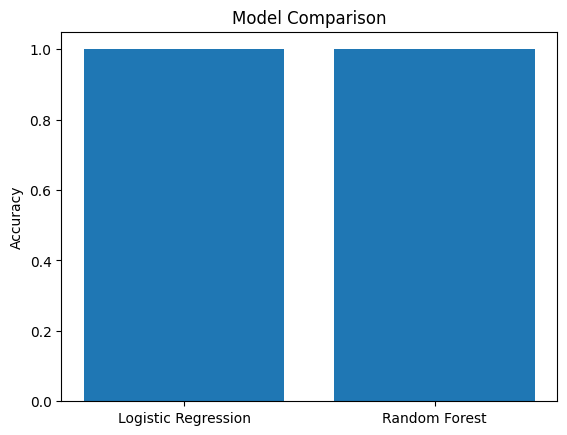

In [8]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Random Forest']
accuracies = [accuracy, rf_accuracy]

plt.bar(models, accuracies)
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.show()

In [9]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average CV Score:", scores.mean())

Cross Validation Scores: [0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
Average CV Score: 0.9666666666666668


In [10]:
from sklearn.metrics import roc_auc_score

rf_prob = rf.predict_proba(X_test)

roc_auc = roc_auc_score(y_test, rf_prob, multi_class='ovr')

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 1.0


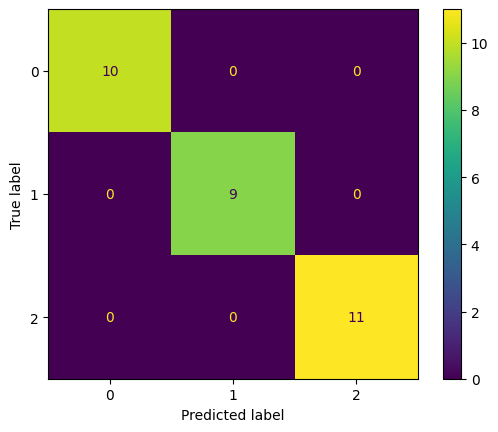

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()